# MSI Prediction from Colorectal Cancer Histopathology (CNN)

**Simple version — one task per cell, dataset saved permanently in Google Drive
(download only once, ever).**

### Pipeline
1. Mount Google Drive
2. Check if dataset already in Drive (download only if missing)
3. Copy dataset from Drive to local disk (faster than working directly on Drive)
4. Build manifest (list of all image paths + labels + patient IDs)
5. Patient-level train/val/test split
6. Dataset class + augmentation
7. Model (ResNet-50)
8. Training loop
9. Test evaluation (AUROC, Sensitivity, Specificity)
10. Grad-CAM
11. Save model to Drive (permanently, so no need to re-download later)

**Before running:** Runtime → Change runtime type → GPU (T4).
**Run cells one at a time, top to bottom.**


## Step 1: Install libraries

In [1]:
!pip install -q grad-cam
print("Libraries installed.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 35.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Libraries installed.


## Step 2: Import + check GPU

In [2]:
import os
import re
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, roc_curve, classification_report
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type != "cuda":
    print("WARNING: GPU not detected! Go to Runtime -> Change runtime type -> GPU, "
          "then Runtime -> Restart session, then re-run this cell before continuing.")


Using device: cuda


## Step 3: Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# This folder in your Drive will permanently store the dataset zip files.
DRIVE_DATA_DIR = "/content/drive/MyDrive/msi_project/data"
os.makedirs(DRIVE_DATA_DIR, exist_ok=True)
print("Drive folder ready at:", DRIVE_DATA_DIR)


Mounted at /content/drive
Drive folder ready at: /content/drive/MyDrive/msi_project/data


## Step 4: Download dataset to Drive (only runs if not already there)

This is the important part: it checks if the zip files already exist in your
Drive. If you already downloaded them in a previous session, this cell skips
the download completely and just says "already exists".


In [4]:
msimut_zip = os.path.join(DRIVE_DATA_DIR, "CRC_DX_TRAIN_MSIMUT.zip")
mss_zip = os.path.join(DRIVE_DATA_DIR, "CRC_DX_TRAIN_MSS.zip")

if os.path.exists(msimut_zip):
    print("MSIMUT zip already in Drive, skipping download.")
else:
    print("Downloading MSIMUT zip to Drive (one-time, ~5GB, will take a while)...")
    !wget -q --show-progress -O {msimut_zip} https://zenodo.org/record/2530835/files/CRC_DX_TRAIN_MSIMUT.zip

if os.path.exists(mss_zip):
    print("MSS zip already in Drive, skipping download.")
else:
    print("Downloading MSS zip to Drive (one-time, ~5GB, will take a while)...")
    !wget -q --show-progress -O {mss_zip} https://zenodo.org/record/2530835/files/CRC_DX_TRAIN_MSS.zip

print("Done. Both zip files are now safely stored in your Drive for future sessions.")


/content/drive/MyDr 100%[===================>]   4.89G  22.5MB/s    in 15m 51s 
/content/drive/MyDr 100%[===================>]   4.90G  18.7MB/s    in 18m 6s  
Done. Both zip files are now safely stored in your Drive for future sessions.


## Step 5: Copy zips to local disk and extract

Working directly on Drive is slow for thousands of small files, so we copy
the zip files to the fast local Colab disk first, then extract there.


In [5]:
LOCAL_DATA_DIR = "/content/dataset"
os.makedirs(f"{LOCAL_DATA_DIR}/MSIMUT", exist_ok=True)
os.makedirs(f"{LOCAL_DATA_DIR}/MSS", exist_ok=True)

local_msimut_zip = "/content/train_msimut.zip"
local_mss_zip = "/content/train_mss.zip"

print("Copying zip files from Drive to local disk...")
shutil.copy(msimut_zip, local_msimut_zip)
shutil.copy(mss_zip, local_mss_zip)
print("Copy done.")

print("Extracting...")
!unzip -q -n {local_msimut_zip} -d {LOCAL_DATA_DIR}/MSIMUT
!unzip -q -n {local_mss_zip} -d {LOCAL_DATA_DIR}/MSS
print("Extraction done.")


Copying zip files from Drive to local disk...
Copy done.
Extracting...
Extraction done.


## Step 6: Build the manifest

A manifest is just a table: image path, label (MSI-High=1 or MSS=0), and
patient ID (extracted from the filename, since filenames contain the TCGA
patient barcode).


In [6]:
def get_patient_id(filename):
    # filenames look like: blk-XXXXXXXX-TCGA-AA-1234-01Z-00-DX1.png
    # we pull out the "TCGA-AA-1234" part as the patient ID
    match = re.search(r"(TCGA-\w{2}-\w{4})", filename)
    if match:
        return match.group(1)
    return filename  # fallback if no match found

label_map = {"MSIMUT": 1, "MSS": 0}
rows = []

for folder_name, label in label_map.items():
    folder_path = os.path.join(LOCAL_DATA_DIR, folder_name)
    for root, _, files in os.walk(folder_path):
        for fname in files:
            if fname.lower().endswith(".png"):
                rows.append({
                    "image_path": os.path.join(root, fname),
                    "label": label,
                    "patient_id": get_patient_id(fname),
                })

manifest = pd.DataFrame(rows)
print(f"Total patches: {len(manifest)}")
print(f"Unique patients: {manifest['patient_id'].nunique()}")
print(manifest["label"].value_counts().rename({1: "MSI-High", 0: "MSS"}))


Total patches: 93408
Unique patients: 260
label
MSI-High    46704
MSS         46704
Name: count, dtype: int64


## Step 7: (Optional but recommended) Use a smaller subset

Training on all ~93,000 patches takes a long time even on GPU. Taking a
balanced subset makes training much faster while still giving a realistic
result. Skip this cell if you want to use the full dataset.


In [7]:
PATCHES_PER_CLASS = 6000  # change this number if you want more/less data

n_per_class = min(PATCHES_PER_CLASS, manifest["label"].value_counts().min())
manifest = (
    manifest.groupby("label", group_keys=False)
    .sample(n=n_per_class, random_state=42)
    .reset_index(drop=True)
)
print(f"Using {len(manifest)} patches after subsetting.")
print(manifest["label"].value_counts().rename({1: "MSI-High", 0: "MSS"}))


Using 12000 patches after subsetting.
label
MSS         6000
MSI-High    6000
Name: count, dtype: int64


## Step 8: Patient-level train / val / test split (prevents data leakage)

In [8]:
def split_by_patient(df, val_size=0.15, test_size=0.15, seed=42):
    # get one label per patient (their majority label)
    patients = df.groupby("patient_id")["label"].agg(lambda x: x.value_counts().idxmax()).reset_index()

    train_patients, temp_patients = train_test_split(
        patients, test_size=(val_size + test_size),
        stratify=patients["label"], random_state=seed
    )
    val_patients, test_patients = train_test_split(
        temp_patients, test_size=test_size / (val_size + test_size),
        stratify=temp_patients["label"], random_state=seed
    )

    train_df = df[df.patient_id.isin(train_patients.patient_id)].reset_index(drop=True)
    val_df = df[df.patient_id.isin(val_patients.patient_id)].reset_index(drop=True)
    test_df = df[df.patient_id.isin(test_patients.patient_id)].reset_index(drop=True)

    # sanity check: no patient should be in more than one split
    assert set(train_df.patient_id) & set(val_df.patient_id) == set()
    assert set(train_df.patient_id) & set(test_df.patient_id) == set()
    assert set(val_df.patient_id) & set(test_df.patient_id) == set()

    return train_df, val_df, test_df

train_df, val_df, test_df = split_by_patient(manifest)
print(f"Train: {len(train_df)} patches")
print(f"Val:   {len(val_df)} patches")
print(f"Test:  {len(test_df)} patches")
print("No patient overlap between splits — confirmed.")


Train: 8806 patches
Val:   1561 patches
Test:  1633 patches
No patient overlap between splits — confirmed.


## Step 9: Dataset class + image augmentation

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class PatchDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)
        label = torch.tensor(row["label"], dtype=torch.float32)
        return image, label

BATCH_SIZE = 32

train_loader = DataLoader(PatchDataset(train_df, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(PatchDataset(val_df, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(PatchDataset(test_df, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Data loaders ready.")


Data loaders ready.


## Step 10: Build the model (ResNet-50, transfer learning)

In [10]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 1)  # 1 output = probability of MSI-High
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2)

print("Model ready.")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 35.3MB/s]


Model ready.


## Step 11: Define one training/validation epoch

In [11]:
def run_epoch(loader, is_training):
    model.train() if is_training else model.eval()
    total_loss = 0.0
    all_labels, all_probs = [], []

    with torch.set_grad_enabled(is_training):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if is_training:
                optimizer.zero_grad()

            output = model(images).squeeze(1)
            loss = criterion(output, labels)

            if is_training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            all_probs.extend(torch.sigmoid(output).detach().cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    auroc = roc_auc_score(all_labels, all_probs)
    return avg_loss, auroc

print("Training function ready.")


Training function ready.


## Step 12: Run training (tracks best model by validation AUROC)

In [12]:
EPOCHS = 15
CHECKPOINT_DIR = "/content/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pt")

best_val_auroc = 0.0
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_auroc = run_epoch(train_loader, is_training=True)
    val_loss, val_auroc = run_epoch(val_loader, is_training=False)
    scheduler.step(val_auroc)

    print(f"Epoch {epoch}/{EPOCHS} | train_loss={train_loss:.3f} train_auroc={train_auroc:.3f} "
          f"| val_loss={val_loss:.3f} val_auroc={val_auroc:.3f}")

    history.append({"epoch": epoch, "train_loss": train_loss, "train_auroc": train_auroc,
                     "val_loss": val_loss, "val_auroc": val_auroc})

    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        torch.save({"model_state_dict": model.state_dict(), "val_auroc": val_auroc}, best_model_path)
        print(f"  -> new best model saved (val_auroc={val_auroc:.3f})")

print(f"\nTraining finished. Best validation AUROC: {best_val_auroc:.3f}")


Epoch 1/15 | train_loss=0.542 train_auroc=0.801 | val_loss=0.596 val_auroc=0.741
  -> new best model saved (val_auroc=0.741)
Epoch 2/15 | train_loss=0.371 train_auroc=0.915 | val_loss=0.655 val_auroc=0.736
Epoch 3/15 | train_loss=0.283 train_auroc=0.952 | val_loss=0.613 val_auroc=0.806
  -> new best model saved (val_auroc=0.806)
Epoch 4/15 | train_loss=0.228 train_auroc=0.969 | val_loss=0.911 val_auroc=0.723
Epoch 5/15 | train_loss=0.193 train_auroc=0.977 | val_loss=0.954 val_auroc=0.711
Epoch 6/15 | train_loss=0.156 train_auroc=0.985 | val_loss=0.923 val_auroc=0.769
Epoch 7/15 | train_loss=0.104 train_auroc=0.994 | val_loss=1.025 val_auroc=0.751
Epoch 8/15 | train_loss=0.086 train_auroc=0.996 | val_loss=0.979 val_auroc=0.772
Epoch 9/15 | train_loss=0.072 train_auroc=0.997 | val_loss=1.064 val_auroc=0.759
Epoch 10/15 | train_loss=0.069 train_auroc=0.998 | val_loss=0.933 val_auroc=0.768
Epoch 11/15 | train_loss=0.070 train_auroc=0.997 | val_loss=0.998 val_auroc=0.760
Epoch 12/15 | train

## Step 13: Plot training curves

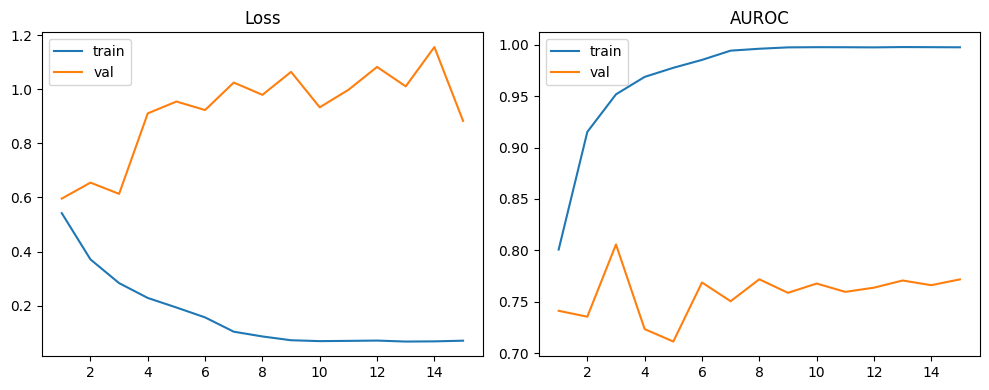

In [13]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(hist_df.epoch, hist_df.train_loss, label="train")
axes[0].plot(hist_df.epoch, hist_df.val_loss, label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist_df.epoch, hist_df.train_auroc, label="train")
axes[1].plot(hist_df.epoch, hist_df.val_auroc, label="val")
axes[1].set_title("AUROC")
axes[1].legend()

plt.tight_layout()
plt.show()


## Step 14: Evaluate on the test set (final numbers)

In [14]:
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_labels, all_probs = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        probs = torch.sigmoid(model(images).squeeze(1)).cpu().tolist()
        all_probs.extend(probs)
        all_labels.extend(labels.tolist())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs >= 0.5).astype(int)

test_auroc = roc_auc_score(all_labels, all_probs)
test_accuracy = accuracy_score(all_labels, all_preds)
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Test AUROC:       {test_auroc:.3f}")
print(f"Test Accuracy:    {test_accuracy:.3f}")
print(f"Sensitivity:      {sensitivity:.3f}  (MSI-High cases correctly caught)")
print(f"Specificity:      {specificity:.3f}  (MSS cases correctly ruled out)")
print()
print(classification_report(all_labels, all_preds, target_names=["MSS", "MSI-High"]))


Test AUROC:       0.755
Test Accuracy:    0.636
Sensitivity:      0.443  (MSI-High cases correctly caught)
Specificity:      0.824  (MSS cases correctly ruled out)

              precision    recall  f1-score   support

         MSS       0.60      0.82      0.70       828
    MSI-High       0.71      0.44      0.55       805

    accuracy                           0.64      1633
   macro avg       0.66      0.63      0.62      1633
weighted avg       0.66      0.64      0.62      1633



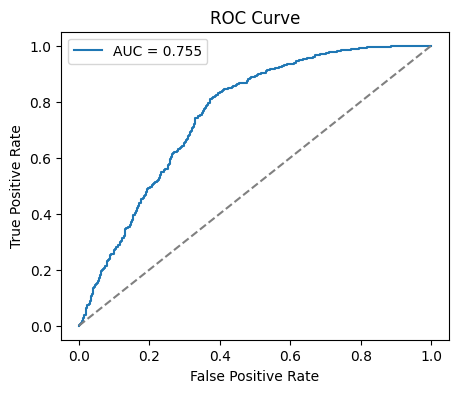

In [15]:
# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {test_auroc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## Step 15: Grad-CAM — see what the model is looking at

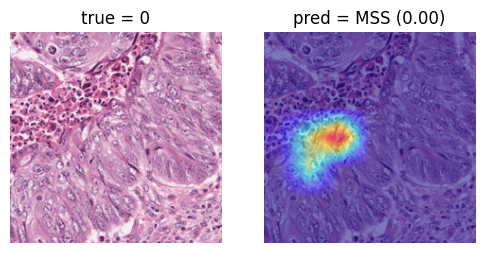

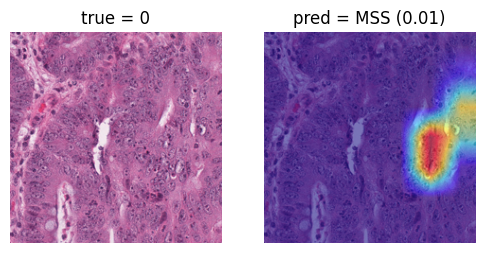

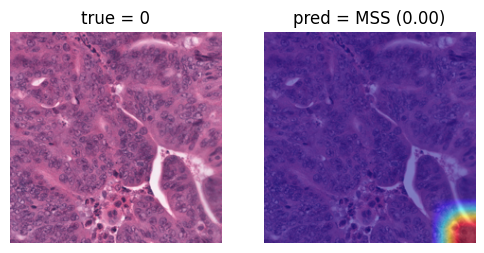

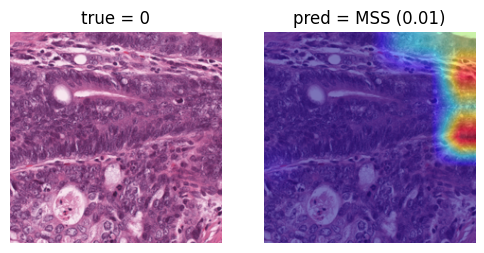

In [16]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

cam_tool = GradCAM(model=model, target_layers=[model.layer4[-1]])

def show_gradcam(row):
    image = Image.open(row["image_path"]).convert("RGB")
    input_tensor = eval_transform(image).unsqueeze(0).to(device)

    heatmap = cam_tool(input_tensor=input_tensor)[0]
    rgb_image = np.array(image.resize((224, 224))).astype(np.float32) / 255.0
    overlay = show_cam_on_image(rgb_image, heatmap, use_rgb=True)

    prob = torch.sigmoid(model(input_tensor).squeeze(1)).item()
    predicted_label = "MSI-High" if prob >= 0.5 else "MSS"

    fig, ax = plt.subplots(1, 2, figsize=(6, 3))
    ax[0].imshow(rgb_image); ax[0].set_title(f"true = {int(row['label'])}"); ax[0].axis("off")
    ax[1].imshow(overlay); ax[1].set_title(f"pred = {predicted_label} ({prob:.2f})"); ax[1].axis("off")
    plt.show()

for i in range(4):
    show_gradcam(test_df.iloc[i])


## Step 16: Save model to Drive (permanent — no need to re-download later)

This saves your trained model to Drive so it's there forever, even after the
Colab session ends. Next time, you can skip training and just load it.


In [17]:
drive_model_path = "/content/drive/MyDrive/msi_project/best_model.pt"
shutil.copy(best_model_path, drive_model_path)
print("Model saved to Drive at:", drive_model_path)
print("You can now download it from Drive whenever you need it for the Streamlit app.")


Model saved to Drive at: /content/drive/MyDrive/msi_project/best_model.pt
You can now download it from Drive whenever you need it for the Streamlit app.
